In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, accuracy_score, classification_report
 
)
import pickle 

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
# load dataset
df = pd.read_csv("NFLX.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200
...,...,...,...,...,...,...,...
5039,2022-05-27,193.190002,195.250000,190.369995,195.190002,195.190002,8586000
5040,2022-05-31,196.179993,199.949997,190.800003,197.440002,197.440002,11398500
5041,2022-06-01,198.699997,202.740005,191.660004,192.910004,192.910004,8416200
5042,2022-06-02,192.020004,205.470001,191.720001,205.089996,205.089996,9623100


In [3]:
# EDA process
print("\n dataset information ")
print(df.info())

print("\n shape of Dataset: ")
print(df.shape)

print("\n First 5 Rows: ")
print(df.head())

print("\n Column Names: ")
print(df.columns)

print("\n Data Types:")
print(df.dtypes)


 dataset information 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5044 entries, 0 to 5043
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       5044 non-null   object 
 1   Open       5044 non-null   float64
 2   High       5044 non-null   float64
 3   Low        5044 non-null   float64
 4   Close      5044 non-null   float64
 5   Adj Close  5044 non-null   float64
 6   Volume     5044 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 276.0+ KB
None

 shape of Dataset: 
(5044, 7)

 First 5 Rows: 
         Date      Open      High       Low     Close  Adj Close     Volume
0  2002-05-23  1.156429  1.242857  1.145714  1.196429   1.196429  104790000
1  2002-05-24  1.214286  1.225000  1.197143  1.210000   1.210000   11104800
2  2002-05-28  1.213571  1.232143  1.157143  1.157143   1.157143    6609400
3  2002-05-29  1.164286  1.164286  1.085714  1.103571   1.103571    6757800
4  2002-05-30 

In [4]:
# data visualization
print("\n statistical Summary:")
print(df.describe())


 statistical Summary:
              Open         High          Low        Close    Adj Close  \
count  5044.000000  5044.000000  5044.000000  5044.000000  5044.000000   
mean    116.467981   118.237392   114.578719   116.456338   116.456338   
std     168.740876   171.140864   166.119837   168.668232   168.668232   
min       0.377857     0.410714     0.346429     0.372857     0.372857   
25%       3.955357     4.031072     3.885357     3.958571     3.958571   
50%      25.819285    26.342143    25.455000    25.802856    25.802856   
75%     155.762497   157.654998   153.944996   155.869999   155.869999   
max     692.349976   700.989990   686.090027   691.690002   691.690002   

             Volume  
count  5.044000e+03  
mean   1.653068e+07  
std    1.924487e+07  
min    2.856000e+05  
25%    6.168225e+06  
50%    1.059135e+07  
75%    1.986552e+07  
max    3.234140e+08  


In [5]:
print("\n Missing values:")
print(df.isnull().sum())


 Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [6]:
# data preprocessing
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day']   = df['Date'].dt.day

df

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000,2002,5,23
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800,2002,5,24
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400,2002,5,28
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800,2002,5,29
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200,2002,5,30
...,...,...,...,...,...,...,...,...,...,...
5039,2022-05-27,193.190002,195.250000,190.369995,195.190002,195.190002,8586000,2022,5,27
5040,2022-05-31,196.179993,199.949997,190.800003,197.440002,197.440002,11398500,2022,5,31
5041,2022-06-01,198.699997,202.740005,191.660004,192.910004,192.910004,8416200,2022,6,1
5042,2022-06-02,192.020004,205.470001,191.720001,205.089996,205.089996,9623100,2022,6,2


In [7]:
df = df.dropna()
print(f" Dataset shape after dropna: {df.shape}")

 Dataset shape after dropna: (5044, 10)


In [8]:
# ── Train / Test Split ──────────────────────────────────────────────────────

In [9]:
# Features and target
x = df[['Year', 'Month', 'Day', 'Open', 'Volume']]
y = df['Close']

In [10]:
# train-test split (shuffle=False keeps time order)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, shuffle=False
)
print(f"Train size: {len(x_train)} | Test size: {len(x_test)}")

Train size: 4035 | Test size: 1009


In [11]:
# Applied StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)
print(" Scaling done")

 Scaling done


In [12]:
# ── MODEL 1: Linear Regression ──────────────────────────────────────────────

In [13]:
lr_model = LinearRegression()
lr_model.fit(x_train_scaled, y_train)
print("Model Training Completed")

# prediction
lr_pred = lr_model.predict(x_test_scaled)

Model Training Completed


In [14]:
print("Predicted:\n", lr_pred[:5])
print("\nActual:\n",   y_test.values[:5])

Predicted:
 [362.80055064 363.43579672 367.89046447 368.64566135 358.15944765]

Actual:
 [361.809998 365.799988 367.450012 361.399994 360.570007]


In [15]:
# Evaluate Linear Regression
lr_mse  = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_r2   = r2_score(y_test, lr_pred)

print("── Linear Regression ──")
print(f"  MSE  : {lr_mse:.4f}")
print(f"  RMSE : {lr_rmse:.4f}")
print(f"  MAE  : {lr_mae:.4f}")
print(f"  R²   : {lr_r2:.4f}")

── Linear Regression ──
  MSE  : 77.6939
  RMSE : 8.8144
  MAE  : 6.5579
  R²   : 0.9937


In [16]:
# Coefficients table
coeff_df = pd.DataFrame(
    lr_model.coef_,
    index=x.columns,
    columns=['Coefficient']
)
print(coeff_df)

        Coefficient
Year       0.024965
Month     -0.008504
Day       -0.044098
Open      62.614877
Volume     0.008322


In [17]:
# ── MODEL 2: Random Forest ──────────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(x_train, y_train)   # tree models don't need scaling
rf_pred = rf_model.predict(x_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("── Random Forest ──")
print(f"  MAE  : {rf_mae:.4f}")
print(f"  RMSE : {rf_rmse:.4f}")
print(f"  R²   : {rf_r2:.4f}")

── Random Forest ──
  MAE  : 85.2689
  RMSE : 124.3123
  R²   : -0.2434


In [30]:
# ── MODEL 3: Decision Tree ──────────────────────────────────────────────────
dt_model = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_model.fit(x_train, y_train)
dt_pred = dt_model.predict(x_test)

dt_mae  = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2   = r2_score(y_test, dt_pred)

print("── Decision Tree ──")
print(f"  MAE  : {dt_mae:.4f}")
print(f"  RMSE : {dt_rmse:.4f}")
print(f"  R²   : {dt_r2:.4f}")

── Decision Tree ──
  MAE  : 80.2961
  RMSE : 118.8588
  R²   : -0.1367


In [31]:
# ── MODEL 4: Logistic Regression (predicts UP=1 / DOWN=0) ──────────────────
# Create binary target: 1 if price went UP vs previous day, else 0
y_dir = (df['Close'].diff() > 0).astype(int)
y_dir = y_dir[x.index]

y_dir_train, y_dir_test = train_test_split(y_dir, test_size=0.2, shuffle=False)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(x_train_scaled, y_dir_train)
log_pred = log_model.predict(x_test_scaled)
log_acc  = accuracy_score(y_dir_test, log_pred)

print("── Logistic Regression ──")
print(f"  Accuracy: {log_acc*100:.2f}%")
print()
print(classification_report(y_dir_test, log_pred, target_names=['DOWN', 'UP']))

── Logistic Regression ──
  Accuracy: 50.45%

              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00       500
          UP       0.50      1.00      0.67       509

    accuracy                           0.50      1009
   macro avg       0.25      0.50      0.34      1009
weighted avg       0.25      0.50      0.34      1009



In [20]:
# ── Model Comparison Table ───────────────────────────────────────────────────
results = pd.DataFrame({
    'Model'   : ['Linear Regression', 'Random Forest', 'Decision Tree', 'Logistic Regression'],
    'MAE ($)' : [f"{lr_mae:.2f}", f"{rf_mae:.2f}", f"{dt_mae:.2f}", 'N/A (classifier)'],
    'RMSE ($)': [f"{lr_rmse:.2f}", f"{rf_rmse:.2f}", f"{dt_rmse:.2f}", 'N/A (classifier)'],
    'R²'      : [f"{lr_r2:.4f}", f"{rf_r2:.4f}", f"{dt_r2:.4f}", 'N/A (classifier)'],
    'Accuracy': ['N/A', 'N/A', 'N/A', f"{log_acc*100:.1f}%"]
})
print(results.to_string(index=False))

              Model          MAE ($)         RMSE ($)               R² Accuracy
  Linear Regression             6.56             8.81           0.9937      N/A
      Random Forest            85.27           124.31          -0.2434      N/A
      Decision Tree            80.30           118.86          -0.1367      N/A
Logistic Regression N/A (classifier) N/A (classifier) N/A (classifier)    50.4%


In [21]:
# ── 60-Day Future Price Prediction ───────────────────────────────────────────

last_row  = df.iloc[-1]
last_date = last_row['Date']          # This is now a proper Timestamp 

n_days = 60
future_dates_list = []
lr_future, rf_future, dt_future = [], [], []

current_open   = last_row['Open']
current_volume = last_row['Volume']

for i in range(1, n_days + 1):
    next_date = last_date + pd.Timedelta(days=i)
    future_dates_list.append(next_date)

    next_day = pd.DataFrame({
        'Year'  : [next_date.year],
        'Month' : [next_date.month],
        'Day'   : [next_date.day],
        'Open'  : [current_open],
        'Volume': [current_volume]
    })

    next_day_scaled = scaler.transform(next_day)

    # Predict with each model
    lr_p = lr_model.predict(next_day_scaled)[0]
    rf_p = rf_model.predict(next_day)[0]
    dt_p = dt_model.predict(next_day)[0]

    lr_future.append(lr_p)
    rf_future.append(rf_p)
    dt_future.append(dt_p)

    # Use Random Forest prediction as next Open (rolling forecast)
    current_open = rf_p

# Build forecast DataFrame
forecast_df = pd.DataFrame({
    'Date'                  : future_dates_list,
    'Linear Regression ($)' : np.round(lr_future, 2),
    'Random Forest ($)'     : np.round(rf_future, 2),
    'Decision Tree ($)'     : np.round(dt_future, 2),
})
forecast_df['Average ($)'] = forecast_df[
    ['Linear Regression ($)', 'Random Forest ($)', 'Decision Tree ($)']
].mean(axis=1).round(2)

print(" 60-Day NFLX Price Forecast")
print("=" * 75)
print(forecast_df.to_string(index=False))
print("=" * 75)

 60-Day NFLX Price Forecast
      Date  Linear Regression ($)  Random Forest ($)  Decision Tree ($)  Average ($)
2022-06-04                 200.28             199.95             201.07       200.43
2022-06-05                 200.09             199.79             201.07       200.32
2022-06-06                 199.93             199.40             201.07       200.13
2022-06-07                 199.52             197.93             197.61       198.35
2022-06-08                 198.05             196.85             194.63       196.51
2022-06-09                 196.97             196.68             194.63       196.09
2022-06-10                 196.79             196.62             194.63       196.01
2022-06-11                 196.73             196.73             194.63       196.03
2022-06-12                 196.83             196.72             194.63       196.06
2022-06-13                 196.82             196.72             194.63       196.06
2022-06-14                 196.81    

In [22]:
# ── Visualizations ──────────────────────────────────────────────────────────

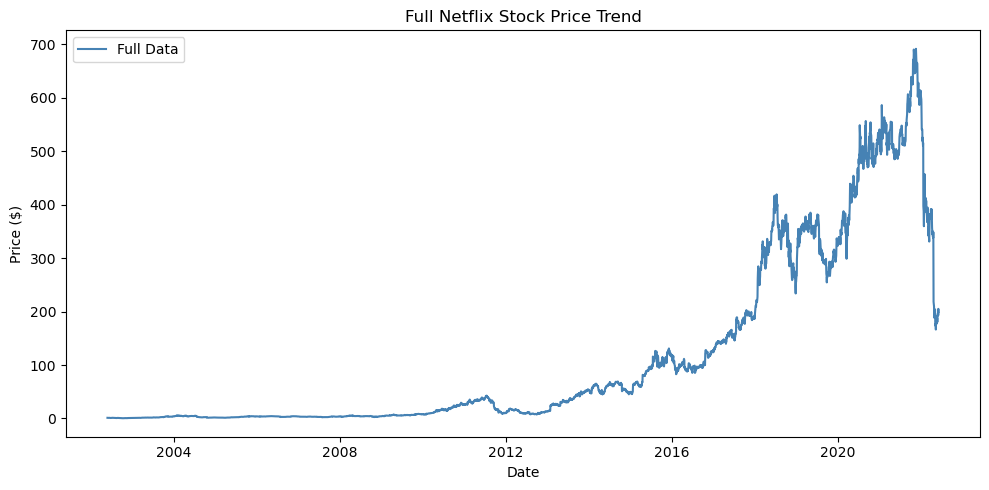

In [23]:
# 1. Full historical price trend
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'], label='Full Data', color='steelblue')
plt.title("Full Netflix Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

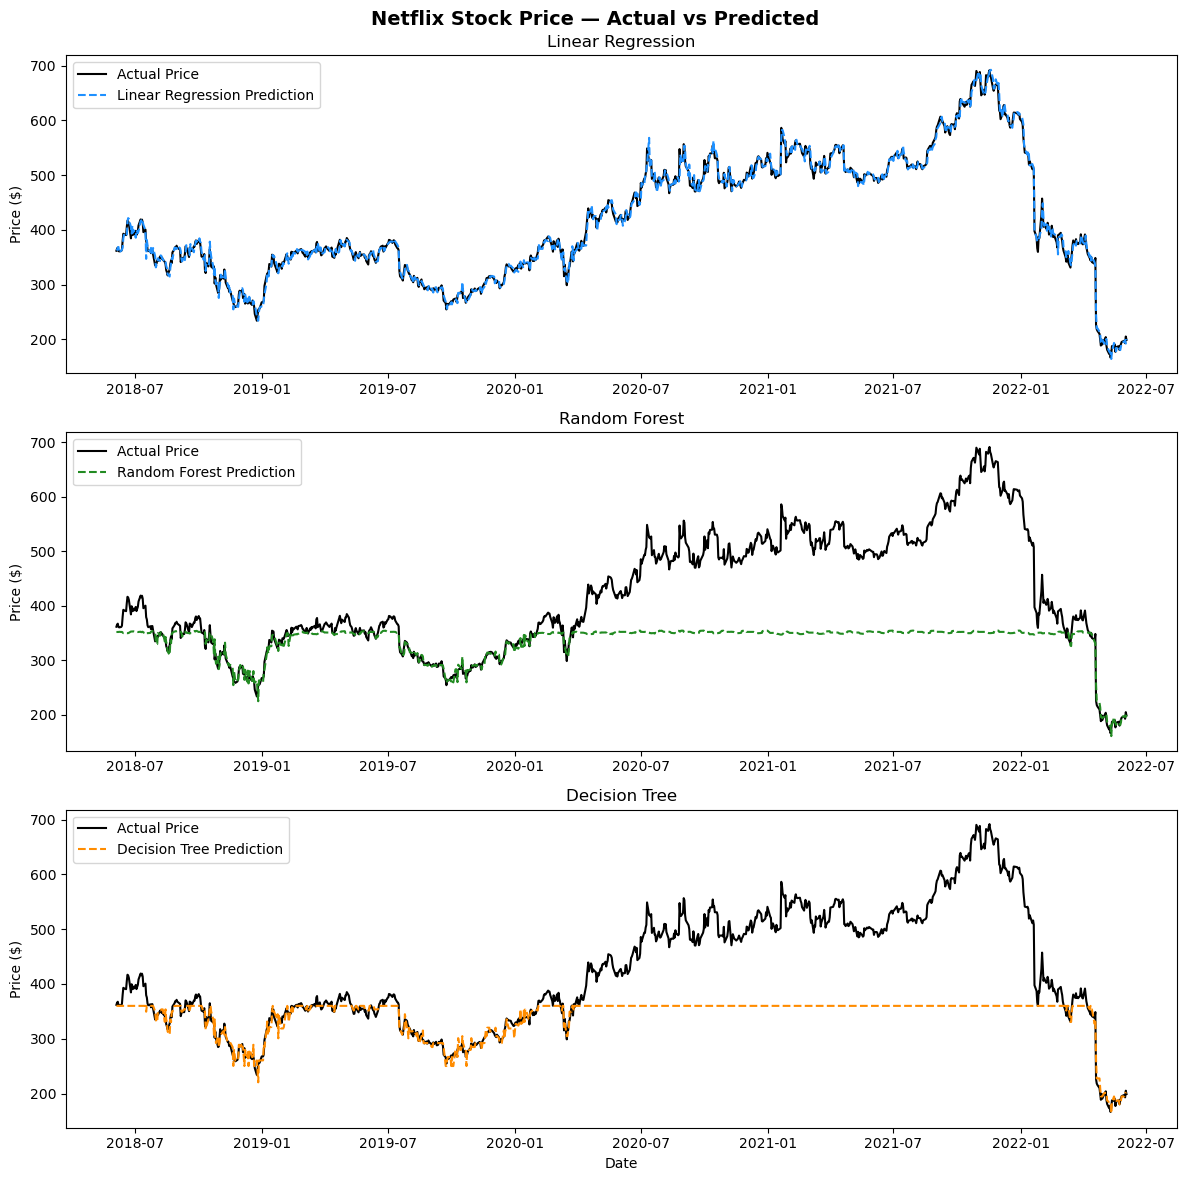

In [24]:
# 2. Actual vs Predicted — all 3 regression models
test_dates = df['Date'].iloc[-len(y_test):].values

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle("Netflix Stock Price — Actual vs Predicted", fontsize=14, fontweight='bold')

for ax, (name, preds, color) in zip(axes, [
    ('Linear Regression', lr_pred, 'dodgerblue'),
    ('Random Forest',     rf_pred, 'forestgreen'),
    ('Decision Tree',     dt_pred, 'darkorange'),
]):
    ax.plot(test_dates, y_test.values, label='Actual Price',        color='black',  linewidth=1.5)
    ax.plot(test_dates, preds,         label=f'{name} Prediction',  color=color,    linewidth=1.5, linestyle='--')
    ax.set_title(name)
    ax.set_ylabel("Price ($)")
    ax.legend()

axes[2].set_xlabel("Date")
plt.tight_layout()
plt.show()

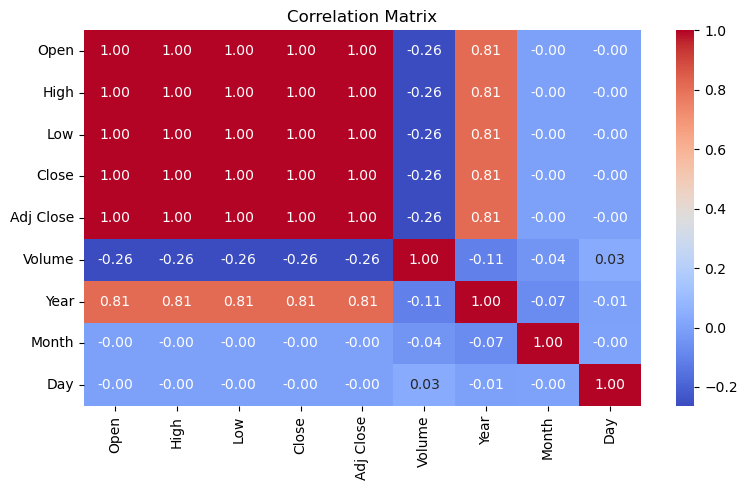

In [25]:
# 3. Correlation heatmap
plt.figure(figsize=(8, 5))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

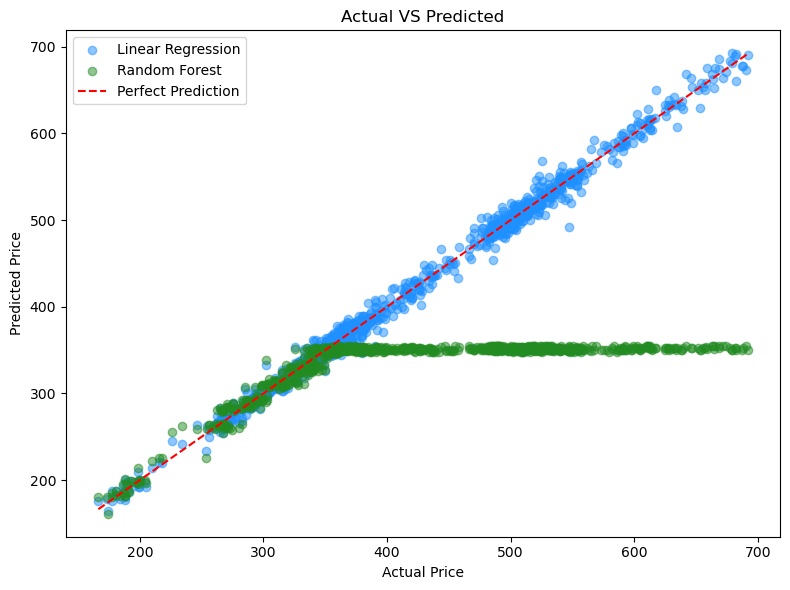

In [26]:
# 4. Scatter plot — Actual vs Predicted (Linear Regression)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_pred, alpha=0.5, color='dodgerblue', label='Linear Regression')
plt.scatter(y_test, rf_pred, alpha=0.5, color='forestgreen', label='Random Forest')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual VS Predicted")
plt.legend()
plt.tight_layout()
plt.show()

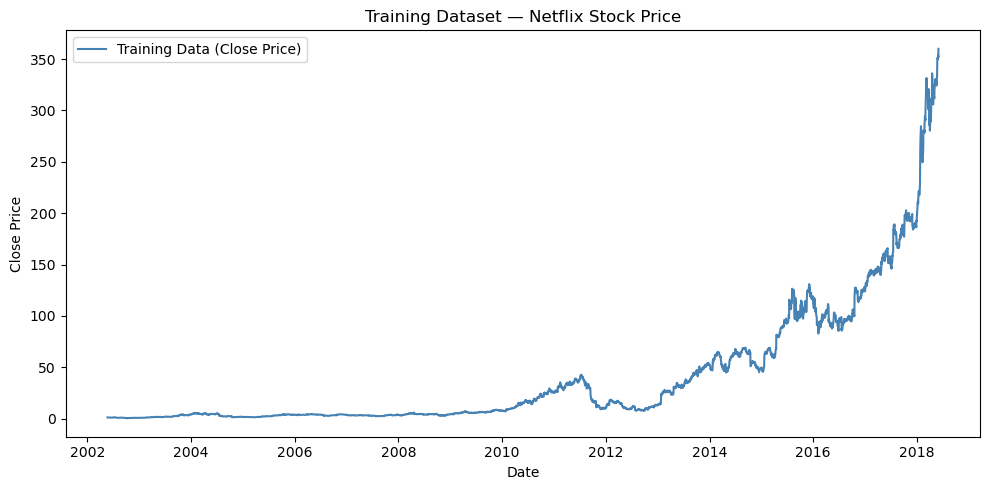

In [27]:
# 5. Training data plot
train_dates = df['Date'].iloc[:len(x_train)]
plt.figure(figsize=(10, 5))
plt.plot(train_dates, y_train.values, label='Training Data (Close Price)', color='steelblue')
plt.title("Training Dataset — Netflix Stock Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()

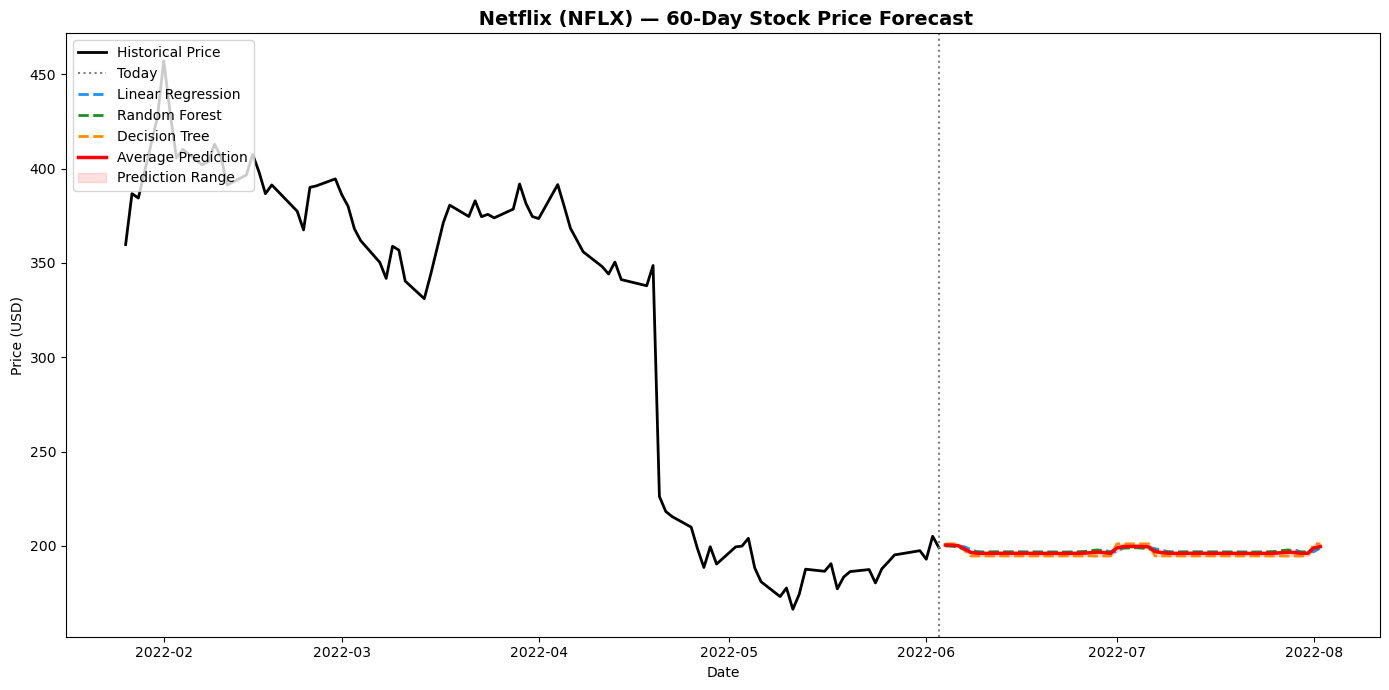


  60-DAY FORECAST SUMMARY
  Current Price : $198.98
  📉 Linear Regression: Day-60 = $198.89  (-0.09 / -0.0%)
  📉 Random Forest: Day-60 = $198.86  (-0.12 / -0.1%)
  📈 Decision Tree: Day-60 = $201.07  (+2.09 / +1.1%)
 For educational purposes only. Not investment advice.


In [28]:
# 6. 60-Day Future Forecast Chart
history_plot = df.tail(90)   # Show last 90 days as context

plt.figure(figsize=(14, 7))
plt.plot(history_plot['Date'], history_plot['Close'],
         color='black', linewidth=2, label='Historical Price')

plt.axvline(x=last_date, color='gray', linestyle=':', linewidth=1.5, label='Today')

plt.plot(forecast_df['Date'], forecast_df['Linear Regression ($)'],
         color='dodgerblue',  linewidth=2, linestyle='--', label='Linear Regression')
plt.plot(forecast_df['Date'], forecast_df['Random Forest ($)'],
         color='forestgreen', linewidth=2, linestyle='--', label='Random Forest')
plt.plot(forecast_df['Date'], forecast_df['Decision Tree ($)'],
         color='darkorange',  linewidth=2, linestyle='--', label='Decision Tree')
plt.plot(forecast_df['Date'], forecast_df['Average ($)'],
         color='red', linewidth=2.5, label='Average Prediction')

# Shade uncertainty band
plt.fill_between(
    forecast_df['Date'],
    forecast_df[['Linear Regression ($)', 'Random Forest ($)', 'Decision Tree ($)']].min(axis=1),
    forecast_df[['Linear Regression ($)', 'Random Forest ($)', 'Decision Tree ($)']].max(axis=1),
    alpha=0.12, color='red', label='Prediction Range'
)

plt.title(" Netflix (NFLX) — 60-Day Stock Price Forecast", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('NFLX_60day_forecast.png', dpi=150)
plt.show()

# Summary
current_price = df['Close'].iloc[-1]
print(f"\n{'='*50}")
print(f"  60-DAY FORECAST SUMMARY")
print(f"{'='*50}")
print(f"  Current Price : ${current_price:.2f}")
for name, preds in [('Linear Regression', lr_future),
                     ('Random Forest',     rf_future),
                     ('Decision Tree',     dt_future)]:
    chg = preds[-1] - current_price
    pct = chg / current_price * 100
    arrow = '📈' if chg > 0 else '📉'
    print(f"  {arrow} {name}: Day-60 = ${preds[-1]:.2f}  ({chg:+.2f} / {pct:+.1f}%)")
print(f"{'='*50}")
print(" For educational purposes only. Not investment advice.")

In [37]:
# Scaling (needed for LR & SVR)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [53]:
# Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Support Vector Machine": SVR()
}

results = []

# Train & evaluate
for name, model in models.items():
    
    if name in ["Linear Regression", "Support Vector Machine"]:
        model.fit(x_train_scaled, y_train)
        preds = model.predict(x_test_scaled)
    else:
        model.fit(x_train, y_train)
        preds = model.predict(x_test)
    
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results.append([name, mae, r2])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "MAE", "R2 Score"])

# Sort by best R2
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print("\nModel Comparison:\n")
print(results_df)

# Best model
best_model_name = results_df.iloc[0]["Model"]
print("\nBest Model is:", best_model_name)


Model Comparison:

                    Model         MAE  R2 Score
0       Linear Regression    6.557887  0.993748
2           Decision Tree   80.296069 -0.136738
1           Random Forest   85.268938 -0.243443
3  Support Vector Machine  327.715235 -9.270530

Best Model is: Linear Regression


In [62]:
model_map = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "Decision Tree": dt_model,
    
}

best_model = model_map[best_model_name]
print('model_choose')

model_choose


In [64]:
import pickle

with open("best_model.pkl", "wb") as f:
  pickle.dump(best_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model saved as best_model.pkl")

Model saved as best_model.pkl
